#Contenido
- Instalación de Qiskit en Colab
- Importación de paquetes de Qiskit
- Superposición cuántica
    - Circuito 1 Medición `M`
    - Circuito 2 Negación y Medición `X` `M`
    - Circuito 3 Superposición y Medición `H` `M`
- Entrelazamiento cuántico
    - Estados de Bell



# Instalación de Qiskit en Colab
##Primero instalamos Qiskit y otros paquetes que necesitamos

In [1]:
!pip install qiskit qiskit[visualization] qiskit_aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c6e05c082abd4c443b25dbe0b4128cc9a86aecad5013741d43d907f74b94442b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# Importación de paquetes de Qiskit
## Importamos los paquetes
> `QuantumCircuit` es la CLASE de circuitos cuánticos de Qiskit

> `AerSimulator` simula una computadora cuántica ideal

> `transpile` convierte el circuito cuántico en un programa para la computadora cuántica



In [2]:
from qiskit import QuantumCircuit
from qiskit import transpile

from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2

from qiskit.visualization import plot_histogram

# Superposición cuántica
Tenemos dos estados
>\begin{eqnarray}
\left\vert 0\right\rangle =\left(
\begin{array}{c}
1 \\
0\\
\end{array}  
\right) \,\,\,\,\,\,\,\,
\left\vert 1\right\rangle =\left(
\begin{array}{c}
0 \\
1\\
\end{array}  
\right)
\end{eqnarray}

Estos estados son ortonormales

>\begin{eqnarray}
\left\langle 0\right.\left\vert 0 \right\rangle &=&
\left(\begin{array}{cc} 1 & 0\\ \end{array} \right)
\left(\begin{array}{c} 1 \\ 0\\ \end{array} \right) = 1\\
\left\langle 1\right.\left\vert 1 \right\rangle
&=&\left(\begin{array}{cc} 0 & 1\\ \end{array} \right)
\left(\begin{array}{c} 0 \\ 1\\ \end{array} \right)= 1\\
\left\langle 0\right.\left\vert 1 \right\rangle
&=&\left(\begin{array}{cc} 1 & 0\\ \end{array} \right)
\left(\begin{array}{c} 0 \\ 1\\ \end{array} \right)= 0\\
\left\langle 1\right.\left\vert 0 \right\rangle
&=&\left(\begin{array}{cc} 0 & 1\\ \end{array} \right)
\left(\begin{array}{c} 1 \\ 0\\ \end{array} \right)= 0
\end{eqnarray}

# Circuito 1
## Construimos el circuito

Los circuitos cuánticos en Qiskit son una instancia de `QuantumCircuit(nq, nc)` donde nq y nc son los números de qubits y de canales clásicos

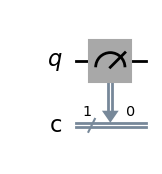

In [6]:
qc = QuantumCircuit(1,1)
qc.measure(0,0)
qc.draw(output='mpl')

## Vemos que mediciones arroja

Primero vemos que ocurre con un solo disparo


In [9]:
backend = AerSimulator()
tran_qc = transpile(qc, backend=backend)
shots = 1
result = backend.run(tran_qc, shots=shots).result()
counts = result.get_counts()
counts

{'0': 1}

Dibujamos el histograma de este resultado

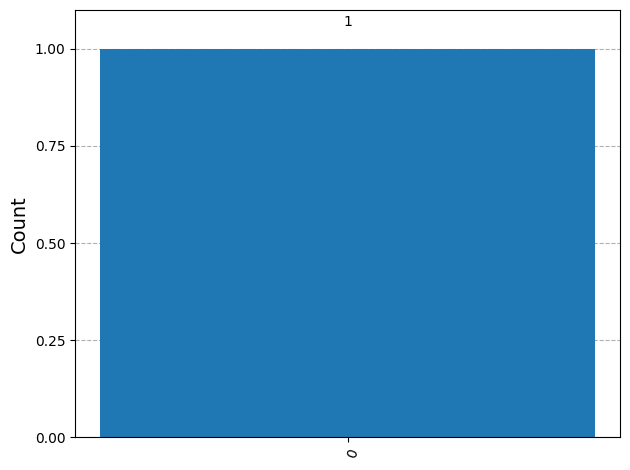

In [10]:
plot_histogram(counts)

## Veamos por qué obtuvimos esos resultados
En este caso mediremos siempre el estado
>\begin{equation}
\left\vert 0\right\rangle =\left(
\begin{array}{c}
1 \\
0\\
\end{array}  
\right)
\end{equation}

porque la computadora cuántica siempre se inicializa en $\left\vert 0\right\rangle$

El estado
>\begin{equation}
\left\vert 1\right\rangle =\left(
\begin{array}{c}
0 \\
1\\
\end{array}  
\right)
\end{equation}

jamás saldra en las mediciones.

Al final imprimimos el circuito

## Vemos que mediciones arroja
Pero ahora con 100 disparos

In [11]:
backend = AerSimulator()
tran_qc = transpile(qc, backend=backend)
shots = 100
result = backend.run(tran_qc, shots=shots).result()
counts = result.get_counts()
counts

{'0': 100}

Dibujamos el histograma

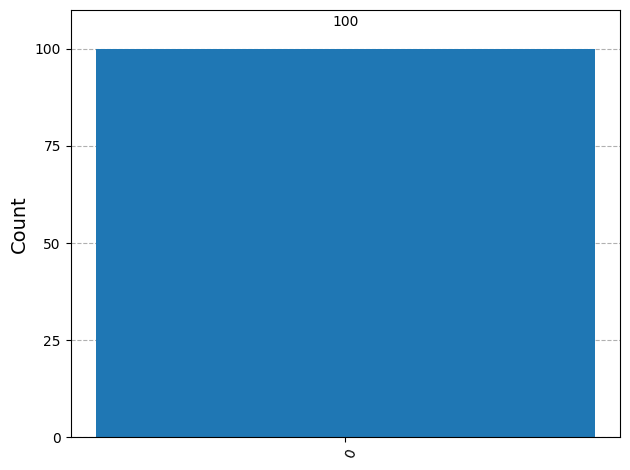

In [12]:
plot_histogram(counts)

Este resultado es esperable ya que la computadora cuántica se inicializa en el estado $\left\vert 0\right\rangle$.

Al medir el estado obtenemos que consistentemente las 100 veces sale $\left\vert 0\right\rangle$.

Y ahora probamos con un backend más realista.

In [13]:
backend = GenericBackendV2(2)
tran_qc = transpile(qc, backend=backend)
shots = 100
result = backend.run(tran_qc, shots=shots).result()
counts = result.get_counts()
counts

{'1': 1, '0': 99}

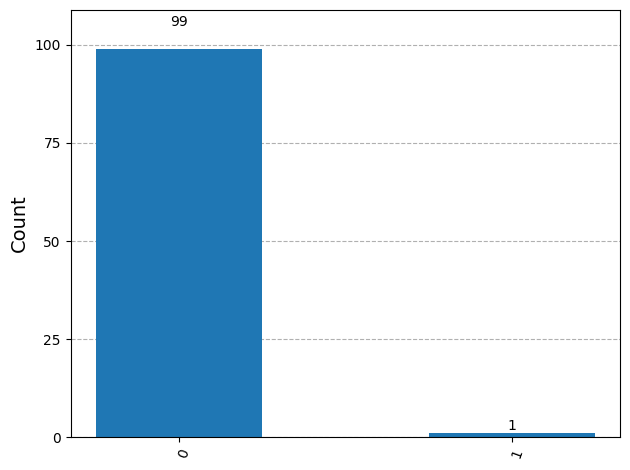

In [14]:
plot_histogram(counts)



Al correr el circuito en un simulador más realista, salen algunos errores

Al medir el estado obtenemos que en la mayor parte de los 100 disparons sale $\left\vert 0\right\rangle$ pero a aveces también sale $\left\vert 1\right\rangle$.


#Circuito 2

Ahora aplicamos una compuerta de negación $X$ antes de la medición.

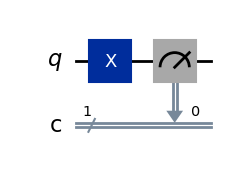

In [15]:
qc = QuantumCircuit(1,1)
qc.x(0)
qc.measure(0,0)
qc.draw(output='mpl')

In [18]:
backend = GenericBackendV2(2)
tran_qc = transpile(qc, backend=backend)
shots = 100
result = backend.run(tran_qc, shots=shots).result()
counts = result.get_counts()
counts

{'0': 1, '1': 99}

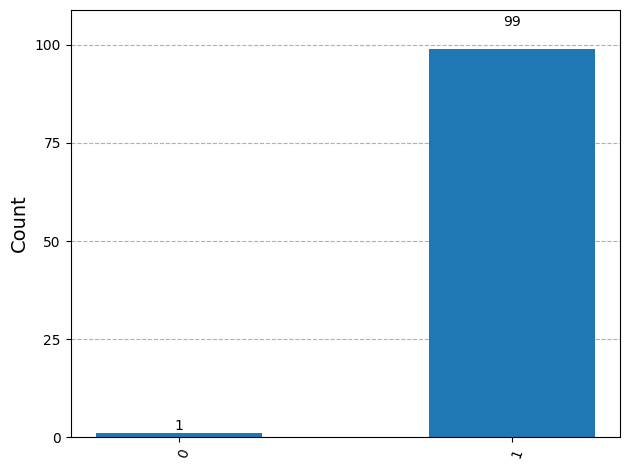

In [19]:
plot_histogram(counts)

# Circuito 3

## Construimos el circuito
De la misma manera que en el circuito 1 esto se hace como una instancia de la clase `QuantumCircuit`. Esta vez vamos a poner una compuerta Hadamard antes de medir. La compuerta Hadamard se puede ver como la matriz
>\begin{equation}
H = \frac{1}{\sqrt{2}}\left(\begin{array}{cc}
1 &  1 \\
1 & -1 \\
\end{array}\right)
\end{equation}

Como la CQ está inicializada en $\left\vert 0 \right\rangle$
entonces
>\begin{equation}
H\left\vert 0 \right\rangle = \frac{1}{\sqrt{2}}\left(\begin{array}{cc}
1 &  1 \\
1 & -1 \\
\end{array}\right)
\left(\begin{array}{c}
1 \\
0 \\
\end{array}\right)
=\frac{1}{\sqrt{2}}\left(\begin{array}{c}
1 \\
1 \\
\end{array}\right)
=\frac{1}{\sqrt{2}}\left\vert 0 \right\rangle
+\frac{1}{\sqrt{2}}\left\vert 1 \right\rangle
\end{equation}

Esto quiere decir que tenemos una probabilidad de $1/2=(1/\sqrt{2})^2$ de obtener
$\left\vert 0 \right\rangle$ y una probabilidad de $1/2$ de obtener
$\left\vert 1 \right\rangle$


Además immprimimos el circuito.

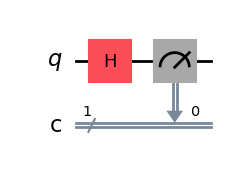

In [23]:
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)
qc.draw(output='mpl')

## Vemos que mediciones arroja
Primero con un sólo disparo

In [24]:
backend = AerSimulator()
tran_qc = transpile(qc, backend=backend)
shots = 1
result = backend.run(tran_qc, shots=shots).result()
counts = result.get_counts()
counts

{'0': 1}

## Dibujamos el histograma

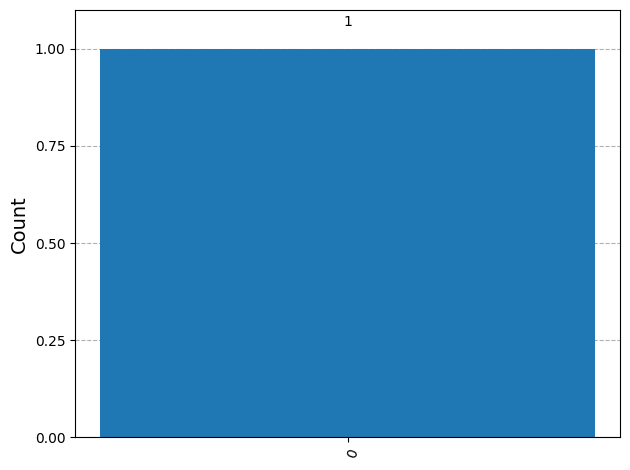

In [25]:
plot_histogram(counts)

Otra vez hacemos un disparo

In [26]:
backend = AerSimulator()
tran_qc = transpile(qc, backend=backend)
shots = 1000
result = backend.run(tran_qc, shots=shots).result()
counts = result.get_counts()
counts

{'0': 483, '1': 517}

## Dibujamos el histograma

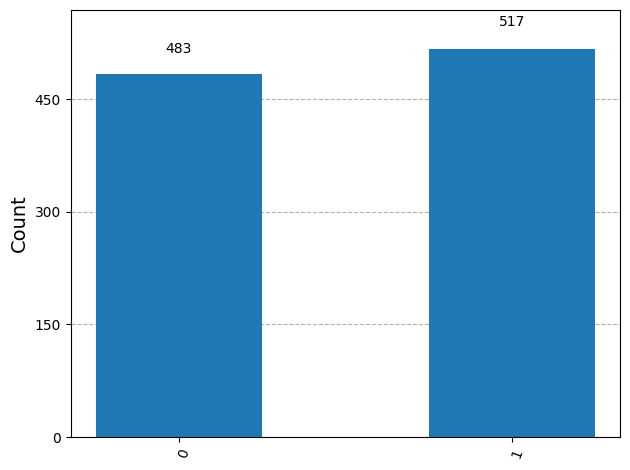

In [27]:

plot_histogram(counts)

Ahora hacemos 1000 disparos

In [28]:
backend = AerSimulator()
tran_qc = transpile(qc, backend=backend)
shots = 10000
result = backend.run(tran_qc, shots=shots).result()
counts = result.get_counts()
counts

{'1': 5008, '0': 4992}

## Dibujamos el histograma

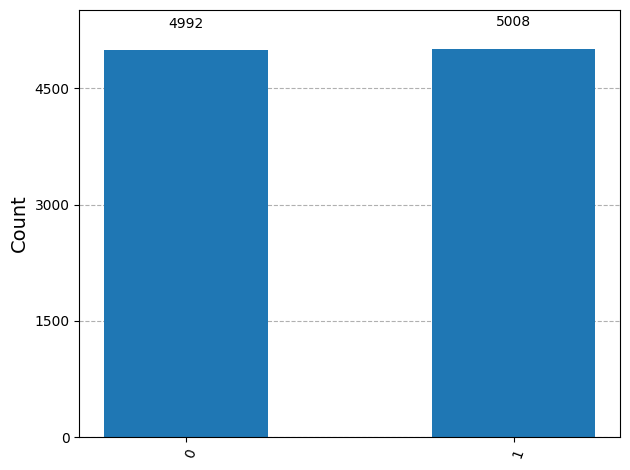

In [29]:
plot_histogram(counts)

## Conclusiones
Este ejemplo es muy diferente al anterior que era muy simple.
En este la probabilidad de obtener los estados $\left\vert 0 \right\rangle$
y $\left\vert 1 \right\rangle$ es de $1/2$. Por esto aproximadamente la mitad
de las veces la medición salió en $0$ y la otra mitad en $1$. En cambio, en el primer circuito obteníamos consistentemente $0$.

# Entrelazamiento cuántico
## Los estados de Bell
>\begin{eqnarray}
\left\vert \phi^+ \right\rangle
&=& \frac{1}{\sqrt{2}}\left\vert 0 \right\rangle \otimes \left\vert 0 \right\rangle
+\frac{1}{\sqrt{2}}\left\vert 1 \right\rangle \otimes \left\vert 1 \right\rangle \\
\left\vert \phi^- \right\rangle
&=& \frac{1}{\sqrt{2}}\left\vert 0 \right\rangle \otimes \left\vert 0 \right\rangle
-\frac{1}{\sqrt{2}}\left\vert 1 \right\rangle \otimes \left\vert 1 \right\rangle \\
\left\vert \psi^+ \right\rangle
&=& \frac{1}{\sqrt{2}}\left\vert 0 \right\rangle \otimes \left\vert 1 \right\rangle
+\frac{1}{\sqrt{2}}\left\vert 1 \right\rangle \otimes \left\vert 0 \right\rangle \\
\left\vert \psi^- \right\rangle
&=& \frac{1}{\sqrt{2}}\left\vert 0 \right\rangle \otimes \left\vert 1 \right\rangle
-\frac{1}{\sqrt{2}}\left\vert 1 \right\rangle \otimes \left\vert 0 \right\rangle
\end{eqnarray}

- Por ejemplo, en el caso de $\left\vert \phi^+ \right\rangle$:
    -  si $q_0$ está en $\left\vert 0 \right\rangle$ $\rightarrow$ $q_1$ está en $\left\vert 0 \right \rangle$.
    -  si $q_0$ está en $\left\vert 1 \right\rangle$ $\rightarrow$ $q_1$ está en $\left\vert 1 \right \rangle$.
- Por ejemplo, en el caso de $\left\vert \psi^+ \right\rangle$:
    -  si $q_0$ está en $\left\vert 0 \right\rangle$ $\rightarrow$ $q_1$ está en $\left\vert 1 \right \rangle$.
    -  si $q_0$ está en $\left\vert 1 \right\rangle$ $\rightarrow$ $q_1$ está en $\left\vert 0 \right \rangle$.

## La compuerta CNOT
Requiere dos qubits $CNOT= CX$

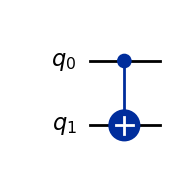

In [30]:
qc = QuantumCircuit(2)
qc.cx(0,1)
qc.draw(output='mpl')

Tiene la forma matemática

>\begin{eqnarray}
CX = I\otimes P_0+X\otimes P_1
\end{eqnarray}

donde $P_0=\left\vert 0\right\rangle\left\langle 0\right\vert$ y $P_1=\left\vert 1\right\rangle\left\langle 1\right\vert$ se llaman proyectores.

Estos tienen las siguientes propiedades
>\begin{eqnarray}
P_0\left\vert 0\right\rangle &=& \left\vert 0\right\rangle\left\langle 0\right.\left\vert 0 \right\rangle = \left\vert 0\right\rangle\\
P_0\left\vert 1\right\rangle &=& \left\vert 0\right\rangle\left\langle 0\right.\left\vert 1 \right\rangle = 0 \\
P_1\left\vert 1\right\rangle &=& \left\vert 1\right\rangle\left\langle 1\right.\left\vert 1 \right\rangle = \left\vert 1\right\rangle\\
P_1\left\vert 0\right\rangle &=& \left\vert 1\right\rangle\left\langle 1\right.\left\vert 0 \right\rangle = 0 \\
\end{eqnarray}

Recuerda que son ortonormales

>\begin{eqnarray}
\left\langle 0\right.\left\vert 0 \right\rangle &=& \left\langle 1\right.\left\vert 1 \right\rangle = 1\\
\left\langle 0\right.\left\vert 1 \right\rangle &=& \left\langle 1\right.\left\vert 0 \right\rangle = 0
\end{eqnarray}

#Circuito 4

El circuito que vemos abajo sirve para producir uno de los estados de Bell. Veamos cuál de los estados de Bell se produce
\begin{eqnarray}
&&\left[I\otimes P_0+X\otimes P_1\right]
\left[I \otimes H\right] \left[X\otimes X\right]\left[\left\vert 0\right\rangle \otimes \left\vert 0\right\rangle \right]\\
&=&\left[I\otimes P_0+X\otimes P_1\right]
\left[I \otimes H\right]
\left[ X\left\vert 0\right\rangle \otimes X\left\vert 0\right\rangle\right]\\
&=&\left[I\otimes P_0+X\otimes P_1\right]
\left[I \otimes H\right]
\left[ \left\vert 1\right\rangle \otimes \left\vert 1\right\rangle\right]\\
&=&\left[I\otimes P_0+X\otimes P_1\right]
\left[ I\left\vert 1\right\rangle \otimes H\left\vert 1\right\rangle\right]\\
&=&\left[I\otimes P_0+X\otimes P_1\right]
\left[\left\vert 1\right\rangle
\otimes \left(\frac{1}{\sqrt{2}}\left\vert 0\right\rangle
-\frac{1}{\sqrt{2}}\left\vert 1\right\rangle\right)\right]\\
&=&\bigg[I\left\vert 1\right\rangle
\otimes \left(\frac{1}{\sqrt{2}}P_0\left\vert 0\right\rangle
-\frac{1}{\sqrt{2}}P_0\left\vert 1\right\rangle\right)
+X\left\vert 1\right\rangle
\otimes \left(\frac{1}{\sqrt{2}}P_1\left\vert 0\right\rangle
-\frac{1}{\sqrt{2}}P_1\left\vert 1\right\rangle\right)\bigg]\\
&=&\frac{1}{\sqrt{2}}\left\vert 1\right\rangle
\otimes\left\vert 0\right\rangle
-\frac{1}{\sqrt{2}}\left\vert 0\right\rangle
\otimes\left\vert 1\right\rangle
= -\left\vert \psi^- \right\rangle
\end{eqnarray}

## Construimos un circuito
Ahora vamos a usar dos qbits para hacer producir uno de los estados de Bell.


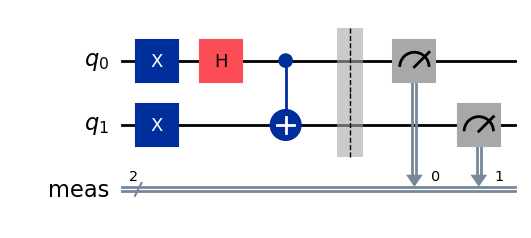

In [31]:
qc = QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.h(0)
qc.cx(0,1)
qc.measure_all()
qc.draw(output='mpl')

In [32]:
backend = AerSimulator()
tran_qc = transpile(qc, backend=backend)
shots = 10000
result = backend.run(tran_qc, shots=shots).result()
counts = result.get_counts()
counts

{'01': 4963, '10': 5037}

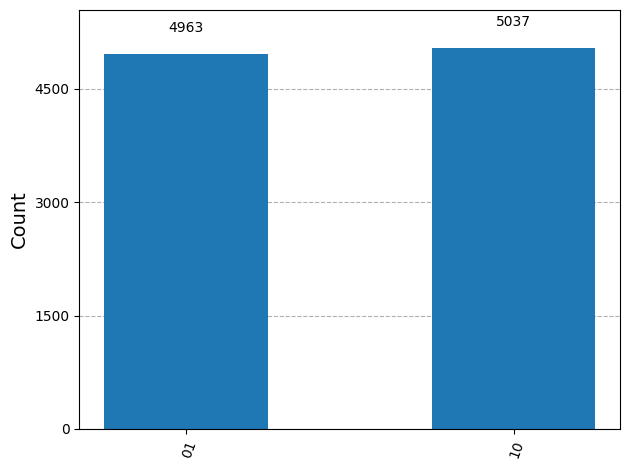

In [33]:
plot_histogram(counts)